# =================================
# Paso 3: SUPPORT VECTOR MACHINE (SVM)
# =================================

Las **Máquinas de Vectores de Soporte (SVM)** son brillantes cuando los datos no se pueden separar con una simple línea recta. Por ejemplo, quizás un autobús está "Lleno" no solo porque el CO2 sea alto, sino por una combinación compleja de CO2 alto *solo* si la ventana está cerrada (lo que afecta la Temperatura y Humedad). El SVM, usando su truco del "Kernel", puede encontrar esas fronteras no lineales en múltiples dimensiones.

1. **Evaluación (Stratified K-Fold + Hold-out):** Mantenemos la estrategia ganadora. 80% para entrenar (usando K-Fold K=5 para validación interna) y 20% para el examen final.
2. **Métricas:** `F1-Score` (para lidiar con el desbalanceo) y `ConfusionMatrixDisplay` para ver si el SVM confunde "Medio" con "Lleno".
3. **Hiperparámetros (Las palancas del SVM):**
* `C (Regularización)`: Controla qué tan "estricto" es el modelo con los errores. Un `C` muy alto puede causar Overfitting.
* `kernel`: Probaremos `linear` (líneas rectas) y `rbf` (curvas complejas).
* `gamma`: Define el "alcance" de la influencia de un solo dato de entrenamiento (vital para el kernel `rbf`).

4. **Escalado Obligatorio:** A diferencia del Random Forest, el **SVM es extremadamente sensible a la escala de los datos**. Si el CO2 va de 400 a 2000, y la temperatura de 20 a 30, el SVM ignorará la temperatura. Integraremos un `StandardScaler` en la tubería (*Pipeline*) de forma nativa para evitar que el modelo falle.


---


### 1. Importar librerias

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay



---


### 2. Montar Google Drive y Cargar

In [ ]:
# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Definir la ruta donde guardaste los archivos en tu Drive
ruta = "/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/LineaC1_Limpio.csv"

Mounted at /content/drive




---



### 3. Entrenamiento: Support Vector Machine (SVM)

--- MODELO AVANZADO: SUPPORT VECTOR MACHINE (SVM) ---

Iniciando GridSearchCV para SVM...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Pipeline SVM (Escalador + Modelo) guardado en: /content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/pipeline_svm_final.joblib

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

   Vacío (0)       0.98      1.00      0.99        46
   Medio (1)       0.96      0.96      0.96        25
   Lleno (2)       1.00      0.90      0.95        10

    accuracy                           0.98        81
   macro avg       0.98      0.95      0.97        81
weighted avg       0.98      0.98      0.98        81



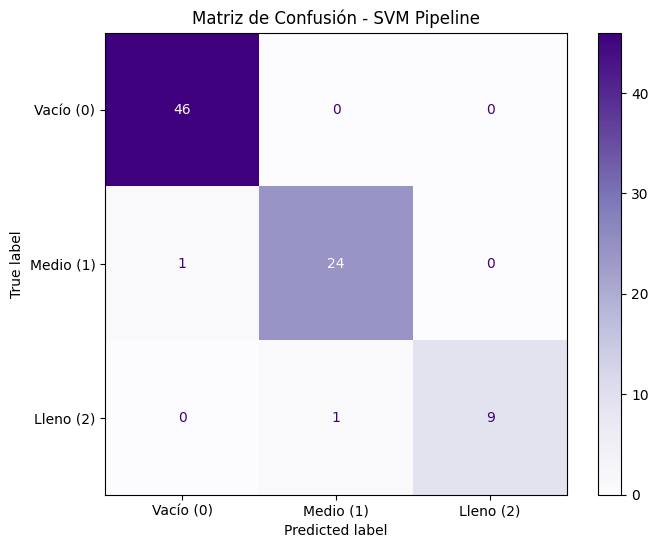

In [ ]:
print("======================================================")
print("--- MODELO AVANZADO: SUPPORT VECTOR MACHINE (SVM) ---")
print("======================================================\n")

# 1. CARGA Y LIMPIEZA DE DATOS (Manteniendo tu ruta original)
df = pd.read_csv(ruta).dropna(subset=['TARGET_Aforo'])

X = df[['Temperatura', 'Humedad', 'eCo2', 'Redes', 'Señal Detectada', 'Hora']]
y = df['TARGET_Aforo'].astype(int)

# 2. PARTICIÓN (80/20 con stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. CREACIÓN DEL PIPELINE
# Encapsulamos el StandardScaler y el SVC
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=42))
])

# 4. HIPERPARÁMETROS (100% Originales de tu notebook)
param_grid_svm = [
    {
        'svm__kernel': ['linear'],
        'svm__C': [0.1, 1, 10, 100]
    },
    {
        'svm__kernel': ['rbf'],
        'svm__C': [0.1, 1, 10, 100],
        'svm__gamma': ['scale', 'auto', 0.1, 1]
    }
]

# 5. TIPO DE EVALUACIÓN: Stratified K-Fold (K=5)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid_svm,
    cv=skf,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("Iniciando GridSearchCV para SVM...")
grid_search_svm.fit(X_train, y_train)

# 6. GUARDAR EL PIPELINE COMPLETO PARA XAI
mejor_pipeline_svm = grid_search_svm.best_estimator_
ruta_resultados = '/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/'
os.makedirs(ruta_resultados, exist_ok=True)
ruta_archivo_svm = os.path.join(ruta_resultados, 'pipeline_svm_final.joblib')

joblib.dump(mejor_pipeline_svm, ruta_archivo_svm)
print(f"✅ Pipeline SVM (Escalador + Modelo) guardado en: {ruta_archivo_svm}")

# 7. EVALUACIÓN FINAL
y_pred = mejor_pipeline_svm.predict(X_test)
target_names = ['Vacío (0)', 'Medio (1)', 'Lleno (2)']

print("\n--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=target_names))

# 8. MATRIZ DE CONFUSIÓN
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    mejor_pipeline_svm, X_test, y_test,
    display_labels=target_names,
    cmap='Purples',
    ax=ax
)
plt.title("Matriz de Confusión - SVM Pipeline")
plt.show()

---

### 4. Conclusiones

1. **¿Qué Kernel eligió el algoritmo?** Si elige `linear`, significa que el CO2 y la Temperatura separan las clases de forma sencilla (como una Regresión Logística). Si elige `rbf`, significa que encontró relaciones complejas ocultas.
2. **¿Pudo igualar el 0.99 del Random Forest?** Anota los resultados. Con estos 3 modelos (LR, RF y SVM) ya tienes la **Comparativa Final** (Punto 4 de tu temario) lista para el Dataset Tabular.